# Anomaly Detection — Autoencoder
This notebook trains a deep learning autoencoder on normal traffic only, then detects anomalies using reconstruction error thresholding.

## 1. Data Loading & Preprocessing

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.preprocessing import load_data
from src.preprocessing import encode_features
from src.preprocessing import split_features

train_data = load_data("../data/raw/KDDTrain+.txt")
test_data = load_data("../data/raw/KDDTest+.txt")

train_data = encode_features(train_data)
test_data = encode_features(test_data)

In [3]:
X_train, y_train = split_features(train_data)
X_test, y_test = split_features(test_data)

## 2. Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3. Autoencoder
### 3.1 Training
Train the autoencoder exclusively on normal traffic. The model learns to reconstruct normal patterns — anomalies will have higher reconstruction error.

In [5]:
from src.autoencoder_model import build_autoencoder

input_dim = X_train.shape[1]

autoencoder = build_autoencoder(input_dim)

normal_train = X_train[y_train == "normal"]

autoencoder.fit(
    normal_train,
    normal_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.5958 - val_loss: 0.2687
Epoch 2/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3757 - val_loss: 0.1712
Epoch 3/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3091 - val_loss: 0.1397
Epoch 4/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2853 - val_loss: 0.1460
Epoch 5/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2608 - val_loss: 0.1093
Epoch 6/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2353 - val_loss: 0.1363
Epoch 7/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2090 - val_loss: 0.0894
Epoch 8/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2052 - val_loss: 0.0936
Epoch 9/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1992 - val_loss: 0.0860
Epoch 10/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2121 - val_loss: 0.1064
Epoch 11/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1736 - val_loss: 0.0846
Epoch 12/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

In [6]:
recon = autoencoder.predict(X_test)

import numpy as np

error = np.mean(np.square(X_test - recon), axis=1)

705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


### 3.2 Threshold Selection
Search for the optimal reconstruction error threshold by maximizing F1-score across percentiles 30–99.

In [7]:
train_recon = autoencoder.predict(normal_train)

from sklearn.metrics import f1_score

true_labels = (test_data["label"] != "normal").astype(int)

best_f1 = 0
best_threshold = 0

for p in range(30, 99):
    t = np.percentile(error, p)
    pred = (error > t).astype(int)
    
    f1 = f1_score(true_labels, pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

2105/2105 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step 
Best threshold: 0.012915540909865682
Best F1: 0.8975194186920571


### 3.3 Evaluation

In [8]:
pred = (error > best_threshold).astype(int)

In [9]:
attack_test = (y_test != "normal").astype(int)

In [10]:
from sklearn.metrics import classification_report

print(classification_report(attack_test, pred))

              precision    recall  f1-score   support

           0       0.96      0.74      0.83      9711
           1       0.83      0.98      0.90     12833

    accuracy                           0.87     22544
   macro avg       0.90      0.86      0.87     22544
weighted avg       0.89      0.87      0.87     22544



In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(attack_test, pred)
print(cm)

[[ 7144  2567]
 [  296 12537]]


### 3.4 PCA Visualization

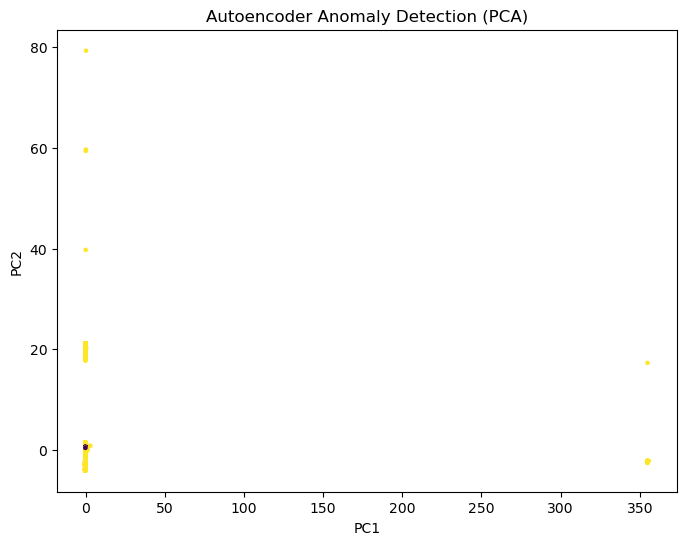

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=pred, s=5)

plt.title("Autoencoder Anomaly Detection (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig("../results/ae_pca.png", bbox_inches='tight')
plt.show()

### 3.5 Reconstruction Error Distribution
Visualize the histogram of reconstruction errors with the selected threshold.

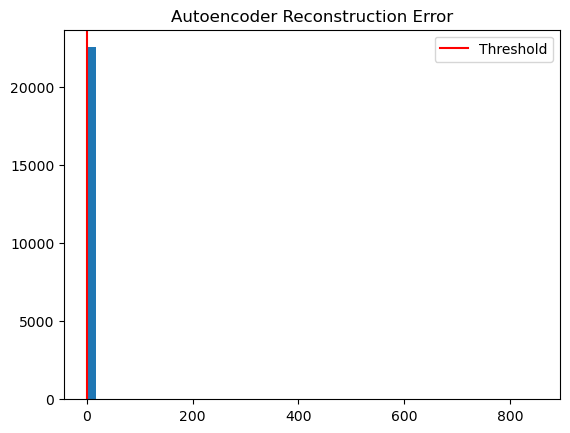

In [13]:
import matplotlib.pyplot as plt

plt.hist(error, bins=50)
plt.axvline(best_threshold, color='red', label='Threshold')
plt.legend()

plt.title("Autoencoder Reconstruction Error")
plt.savefig("../results/ae_error.png")
plt.show()

In [14]:
print("Reconstruction error shows clearer separation compared to IF anomaly scores.")

Reconstruction error shows clearer separation compared to IF anomaly scores.


## 4. Save Model & Metrics

In [15]:
import joblib

joblib.dump(scaler, "../results/scaler.pkl")
autoencoder.save("../results/autoencoder_model.keras")

## 5. Model Comparison
Compare all three models — Isolation Forest, DBSCAN, and Autoencoder — across precision, recall, F1, and accuracy.

In [16]:
import json
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

ae_metrics = {
    "Precision":    round(precision_score(true_labels, pred), 2),
    "Recall":       round(recall_score(true_labels, pred), 2),
    "F1-Score":     round(f1_score(true_labels, pred), 2),
    "Accuracy":     round(accuracy_score(true_labels, pred), 2),
    "Key Behavior": "Reconstruction error thresholding"
}

with open("../results/ae_metrics.json", "w") as f:
    json.dump(ae_metrics, f)

print("AE metrics:", ae_metrics)

AE metrics: {'Precision': 0.83, 'Recall': 0.98, 'F1-Score': 0.9, 'Accuracy': 0.87, 'Key Behavior': 'Reconstruction error thresholding'}


## 6. Conclusion
The Autoencoder outperforms both Isolation Forest and DBSCAN on the NSL-KDD dataset. Deep learning approaches that model the normal data distribution are better suited for network intrusion detection than traditional unsupervised methods.